In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import csv
import os 
import glob 

In [2]:
distributions = [
    "Gamma4sinh", "Gamma3sinh", 
    "Gamma3from02to1", "Gamma2from0to05", 
    "ExpGamma6", "ExpGamma5", 
    "Gamma6", "Gamma5", # "Gamma4",  
    "Quadratic", 
    "01TTPalpha", "05TTPalpha", "2TTPalpha", 
                 ] 

tolerances = [1e-10,1e-15,1e-20,1e-25,1e-30,1e-35,1e-40,1e-45]

L1error = {}
m = {} 
for file in glob.glob("data/RA_DO/L1errors/*.csv"): 
    dist = file.split("dist")[1].split("_m_")[0]
    distributions.append
    tol = float(file.split("_AAAtol_")[1].split(".csv")[0])
    if tol == 1e-20: 
        print(file)
    with open(file, mode="r") as csvfile: 
        csvreader = csv.reader(csvfile)
        L1error[(dist,tol)]= float(next(csvreader)[0])
    m[(dist,tol)] = int(file.split("_m_")[1].split("_AAAtol_")[0])



data/RA_DO/L1errors/distNarrowBump050_m_49_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distGamma4sinh_m_45_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distGamma3_m_44_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distGamma6_m_44_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distMidBump025_m_50_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distMidBump000right_m_50_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distMidBump175_m_46_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distWideBump050_m_49_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distGamma3from02to1_m_44_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distGamma2from0to05_m_49_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/dist05TTPalpha_m_44_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distQuadratic_m_45_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distGamma5_m_44_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distExpGamma6_m_45_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distMidBump05_m_49_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distGamma4_m_44_AAAtol_1.0e-20.csv
data/RA_DO/L1errors/distGamma3sinh_m_44_AAAtol_1.0e-20.c

In [4]:
cmap = plt.get_cmap("Set3")

colors = {}
for idx, dist in enumerate(distributions): 
    r, g, b, alpha = cmap((idx +1.) / (len(distributions)+1))
    r /= 1.25
    g /= 1.25 
    b /= 1.25
    colors[dist] = (r, g, b, 1)
    
labels = {} 
labels["Gamma6"] = r"$\Gamma(6-\alpha)$"
labels["Gamma5"] = r"$\Gamma(5-\alpha)$"
labels["Gamma4"] = r"$\Gamma(4-\alpha)$"
labels["Gamma4sinh"] = r"$\Gamma(4-\alpha) \mathrm{sinh}(\alpha)$"
labels["Gamma3sinh"] = r"$\Gamma(3-\alpha) \mathrm{sinh}(\alpha)$"
labels["01TTPalpha"] = r"$0.1^\alpha$"
labels["05TTPalpha"] = r"$0.5^\alpha$"
labels["2TTPalpha"] = r"$2^\alpha$"
labels["Quadratic"] = r"$\alpha -\alpha^2$"
labels["ExpGamma6"] = r"$e^\alpha \Gamma(6-\alpha)$"
labels["ExpGamma5"] = r"$e^\alpha \Gamma(5-\alpha)$"
labels["Gamma3from02to1"] = r"$\Gamma(3-\alpha)_{[0.2,1]}$"
labels["Gamma2from0to05"] = r"$\Gamma(2-\alpha)_{[0,0.5]}$"

/tmp/ipykernel_865084/2439097760.py:50: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig("Images/Paper/DO_combined.pdf", bbox_inches="tight")
/home/jonas/.local/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/jonas/.local/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


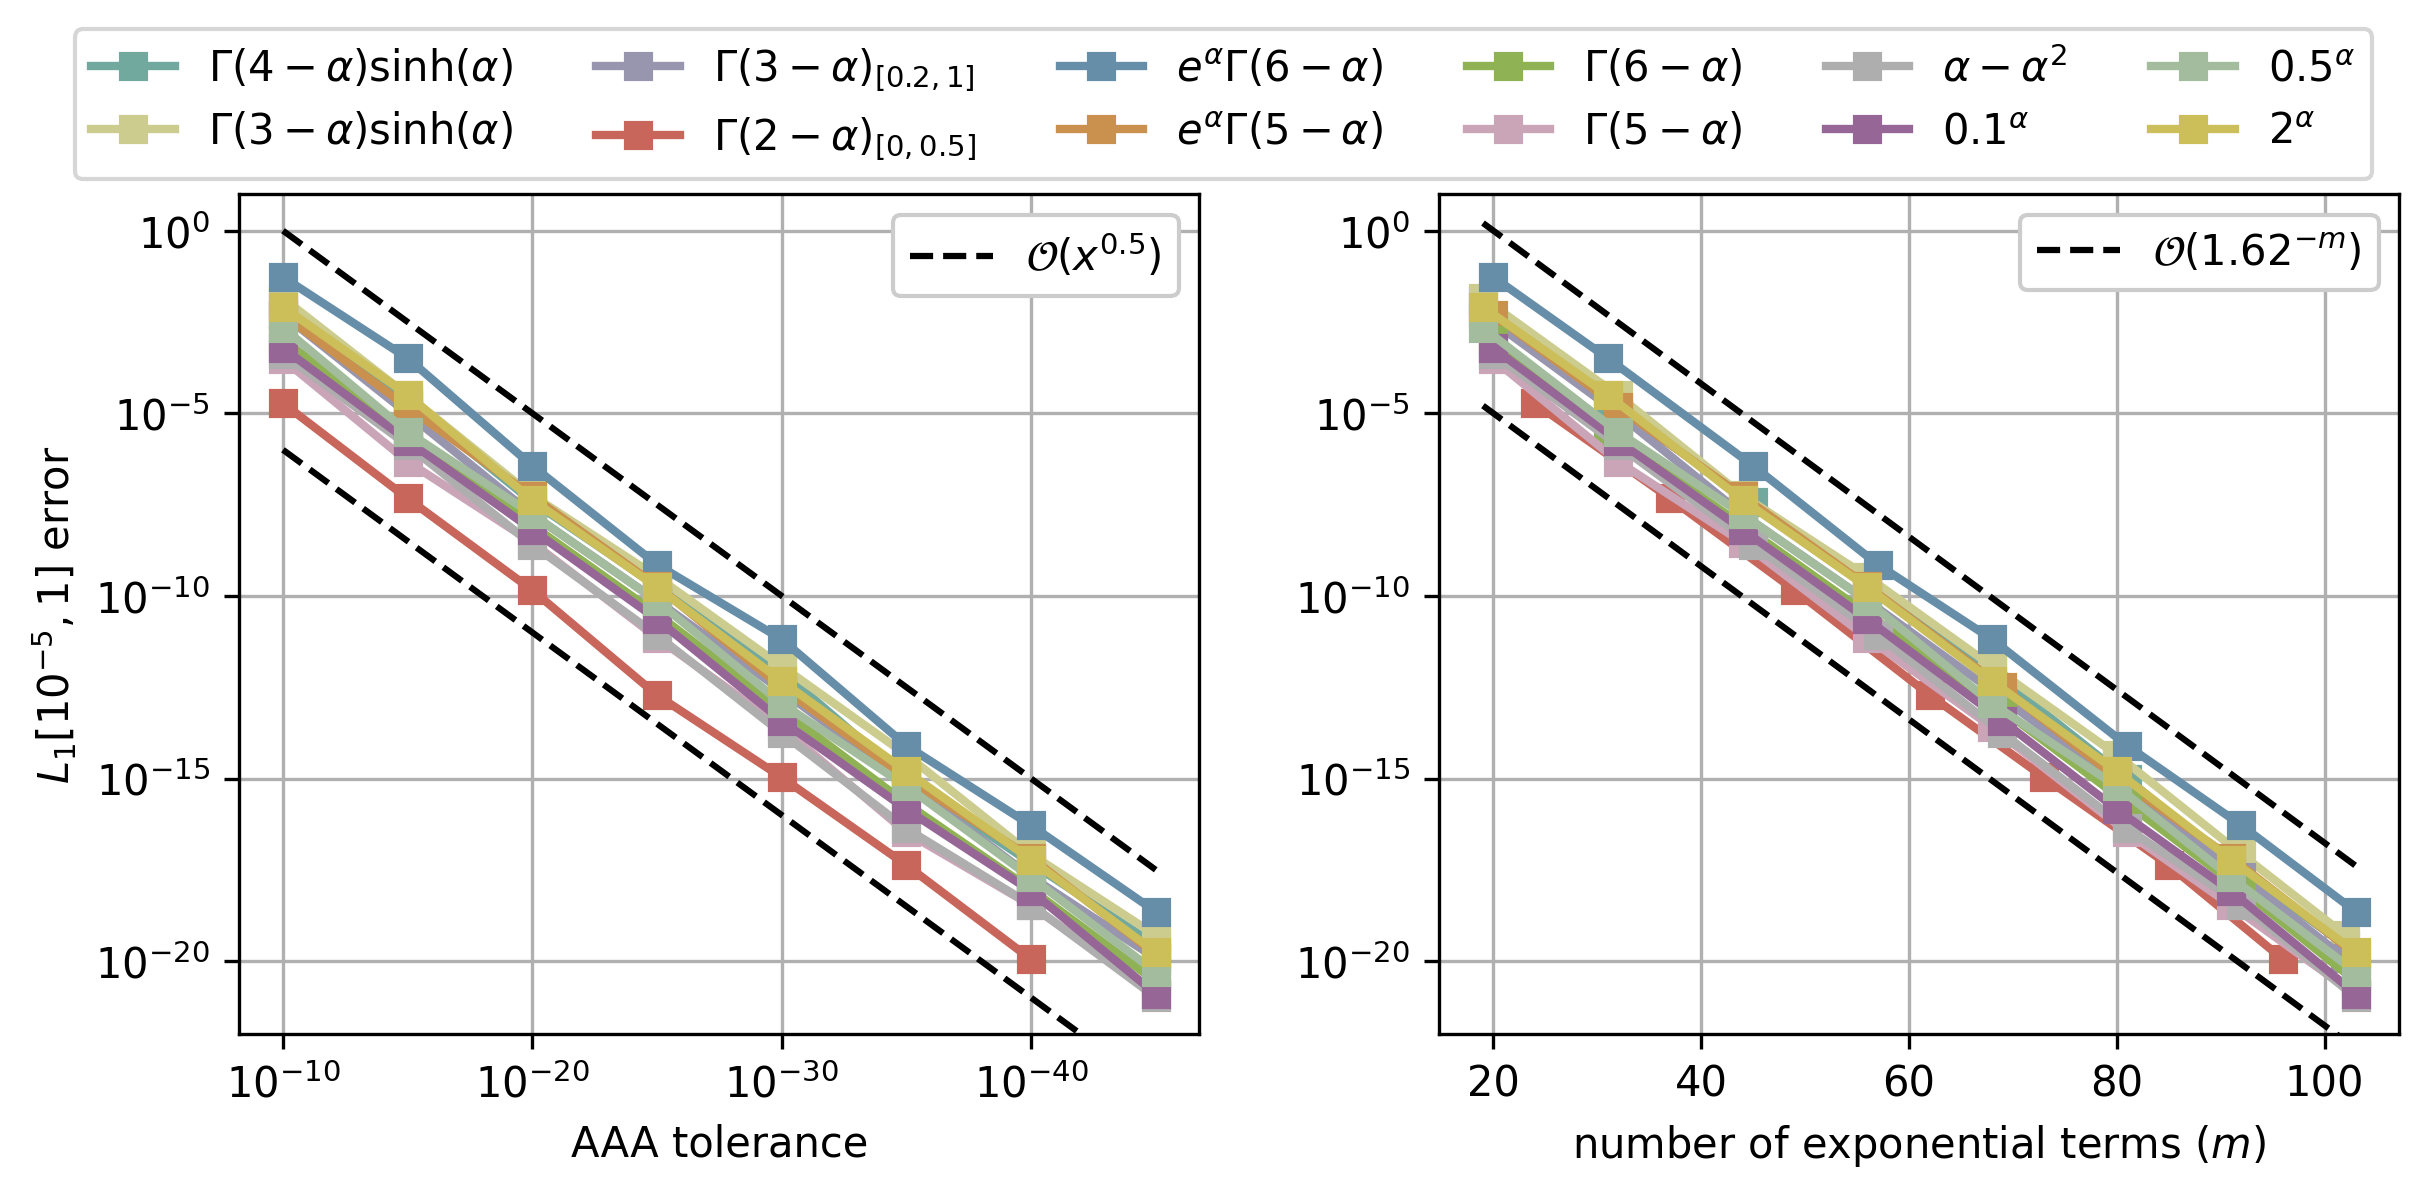

In [10]:
fig = plt.figure(figsize=(8,4), dpi = 300, constrained_layout=True)
ax1 = fig.add_axes([0.05, 0.75, 0.4, 0.7])
ax2 = fig.add_axes([0.55, 0.75, 0.4, 0.7])    

# heuristic lines 
x = 10**np.linspace(-10,-45,100)
ax1.plot(x,1e-1*x**0.5, zorder = 15, linestyle="--", color="black", label=r"$\mathcal{O}(x^{0.5})$")
ax1.plot(x,1e5*x**0.5, zorder = 15, linestyle="--", color="black")

x = np.linspace(19,103,81)
ax2.plot(x,1.62**20 * 1e-5 * 1.62**-x, zorder = 15, linestyle="--", color="black", label=r"$\mathcal{O}(1.62^{-m})$")
ax2.plot(x,1.62**20 * 1.62**-x, zorder = 15, linestyle="--", color="black")

ax1.legend(framealpha=1)
ax2.legend(framealpha=1)

for dist in distributions: 
    errors = [] 
    noet = []
    x_data = [] 
    for tol in tolerances: 
        if (dist, tol) in L1error.keys(): 
            errors.append(L1error[(dist,tol)])
            noet.append(m[(dist,tol)])
            x_data.append(tol)
    ax1.plot(x_data, errors, color = colors[dist], linestyle="-", linewidth=2,  label = labels[dist], zorder=10, marker="s")
    ax2.plot(noet, errors, color = colors[dist], linewidth=2, zorder=10, marker="s")
    
# axis 
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.invert_xaxis()
ax1.set_xticks([1e-10,1e-20,1e-30, 1e-40])
ax1.set_yticks([1e-0, 1e-5,1e-10,1e-15, 1e-20])
ax1.set_ylim([1e-22,1e1])
ax1.grid('on')
ax1.set_xlabel("AAA tolerance")
ax1.set_ylabel(r"$L_1[10^{-5},1]$ error")

ax2.set_yscale("log")
ax2.set_xticks([20,40,60,80,100])
ax2.set_yticks([1e-0, 1e-5,1e-10,1e-15, 1e-20])
ax2.set_ylim([1e-22,1e1])
ax2.grid('on')
ax2.set_xlabel(r"number of exponential terms $(m)$")

h1, l1 = ax1.get_legend_handles_labels()

fig.legend(handles=h1[1:], labels=l1[1:], bbox_to_anchor=(0.46, 1.525), loc="center", ncol=6)
fig.savefig("Images/Paper/DO_combined.pdf", bbox_inches="tight")